<div style="
    background: #111827;
    color: white;
    padding: 35px;
    border-radius: 12px;
    margin-bottom: 25px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
    font-family: Arial, sans-serif;
">

   <h1 style="
        margin: 0;
        font-size: 2.5rem;
        text-align: center;
        text-transform:uppercase
   ">
        Precificando Quartos de Hotéis    <!--  TÍTULO  -->
   </h1>

   <hr style="
        border: none;
        height: 1px;
        background: rgba(255,255,255,0.2);
        margin: 25px 0 10px 0;
   ">
   <div style="
        display: flex;
        flex-direction:column;
        justify-content:center;
        align-items: center;
        flex-wrap: wrap;
        gap: 15px;
        font-size: 0.9rem;
        color: #94a3b8;
   ">
       <span style="font-weight: 500;">
            Por: <strong style="color: white; font-weight: 600;">Wellington M. Santos</strong> - Cientista de Dados
       </span>
       <div style="display: flex; gap: 20px; font-weight: 500;">
            <a href="https://www.linkedin.com/in/wellington-moreira-santos" 
               target="_blank" 
               style="color:#93c5fd; text-decoration:none;">
               LinkedIn
            </a>
            <a href="mailto:wsantos08@hotmail.com" 
               style="color:#93c5fd; text-decoration:none;">
               Contato
            </a>
            <a href="https://github.com/esscova" 
               target="_blank" 
               style="color:#93c5fd; text-decoration:none;">
               GitHub
            </a>
       </div>
   </div>

</div>

## Introdução

Neste projeto, construo modelos de regressão linear para precificar quartos de hotéis a partir de três características: classificação por estrelas, proximidade a pontos turísticos e capacidade de hóspedes. O dataset foi disponibilizado pela Alura como atividade prática do curso. O objetivo é identificar quais variáveis explicam melhor o preço e comparar o desempenho dos modelos à medida que novas variáveis são incluídas.

**Seções deste notebook:**

1. Carregando e conhecendo os dados
2. Análise exploratória com PairPlot
3. Separando em treino e teste
4. Construindo os modelos de regressão linear
5. Comparando os modelos
6. Conclusão
7. Referências

---

## 1. Carregando e conhecendo os dados

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

print('- BIBLIOTECAS CARREGADAS -')
print(f'Versão Python: {sys.version.split()[0]}')

- BIBLIOTECAS CARREGADAS -
Versão Python: 3.13.5


In [3]:
try:
    dados = pd.read_csv("hoteis.csv")
    print('- DADOS CARREGADOS -')
except FileNotFoundError:
    print('Arquivo não encontrado, verifique o caminho')
except Exception as e:
    print(f'Erro: {str(e)}')

- DADOS CARREGADOS -


In [4]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Estrelas            1000 non-null   int64  
 1   ProximidadeTurismo  1000 non-null   float64
 2   Capacidade          1000 non-null   int64  
 3   Preco               1000 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 31.4 KB


In [5]:
dados.head()

,Estrelas,ProximidadeTurismo,Capacidade,Preco
0,5,9.301565,3,506.275452
1,1,1.785891,1,246.363458
2,4,15.504293,3,325.873550
3,4,4.173188,3,521.343284
4,4,9.443685,1,252.587087


In [6]:
dados.describe()

,Estrelas,ProximidadeTurismo,Capacidade,Preco
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.008000,7.650878,2.519000,396.611361
std,1.407095,5.870137,1.108543,171.742433
min,1.000000,0.013850,1.000000,-220.208705
25%,2.000000,3.034775,2.000000,283.590980
50%,3.000000,6.430035,3.000000,401.743527
75%,4.000000,10.863295,4.000000,516.097856
max,5.000000,31.709748,4.000000,836.261308


In [7]:
dados.query('Preco <= 0')

,Estrelas,ProximidadeTurismo,Capacidade,Preco
53,1,23.205943,2,-41.733536
87,3,28.345545,1,-220.208705
229,2,22.259443,2,-13.951666
252,3,25.827966,2,-135.511864
307,1,18.227236,1,-72.942150
345,1,27.593551,1,-150.740785
531,1,19.986395,2,-47.249784
642,3,23.207998,2,-44.456781
755,1,22.904671,2,-93.049061
799,2,19.805656,1,-102.699686


O dataset contém 1.000 registros sem valores ausentes. A tabela abaixo descreve cada variável:

| Variável | Tipo | Descrição |
|---|---|---|
| `Estrelas` | inteiro (1 a 5) | Classificação oficial do hotel |
| `ProximidadeTurismo` | float | Distância em km até o ponto turístico mais próximo |
| `Capacidade` | inteiro (1 a 4) | Número máximo de hóspedes no quarto |
| `Preco` | float | Preço da diária em reais (variável alvo) |

Um detalhe que chama atenção nas estatísticas descritivas: o preço mínimo registrado é negativo. Há 16 registros com `Preco < 0`, todos associados a hotéis com `ProximidadeTurismo` muito alta (acima de 18 km). Trata-se de uma limitação do dataset, possivelmente resultante do processo de geração dos dados. Esses registros não são removidos para manter o exercício alinhado ao proposto pelo curso.

---

## 2 Análise exploratória

<Figure size 800x600 with 0 Axes>

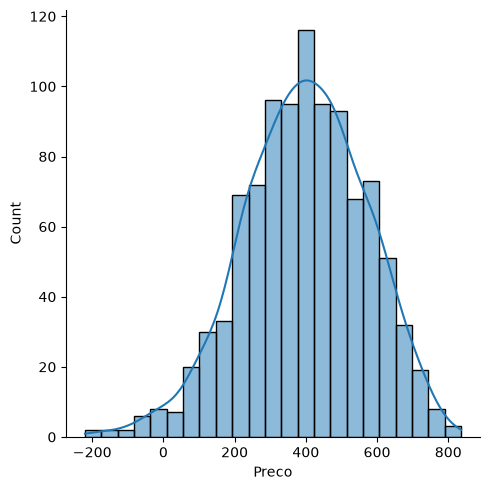

In [35]:
plt.figure(figsize=(8,6))
sns.displot(
    dados.Preco,
    kde=True
)
plt.show()

### 2.1 Análise exploratória com PairPlot

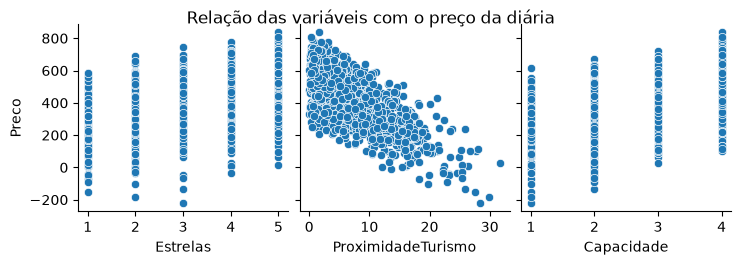

In [8]:
sns.pairplot(dados, y_vars='Preco',
             x_vars=['Estrelas', 'ProximidadeTurismo', 'Capacidade'])
plt.suptitle('Relação das variáveis com o preço da diária', y=1.02)
plt.show()

In [9]:
corr = dados.corr()
corr['Preco'].sort_values(ascending=False)

Preco                 1.000000
Capacidade            0.531866
Estrelas              0.401099
ProximidadeTurismo   -0.697142
Name: Preco, dtype: float64

O PairPlot revela padrões distintos para cada variável:

- `Estrelas` e `Capacidade` têm relação positiva com o preço: hotéis com mais estrelas e quartos com maior capacidade tendem a cobrar diárias mais altas.
- `ProximidadeTurismo` tem relação **negativa** com o preço (correlação de -0,70). Isso é contra-intuitivo à primeira vista, mas faz sentido: hotéis localizados longe dos pontos turísticos precisam reduzir o preço para atrair hóspedes. Quanto maior a distância, menor o apelo da localização e, consequentemente, menor o preço praticado.

As correlações confirmam a mesma ordem de importância: `ProximidadeTurismo` (-0,70) é o preditor mais forte, seguida por `Capacidade` (0,53) e `Estrelas` (0,40).

### 2.2 Análise de correlação e reta ajustada para Preço x Proximidade

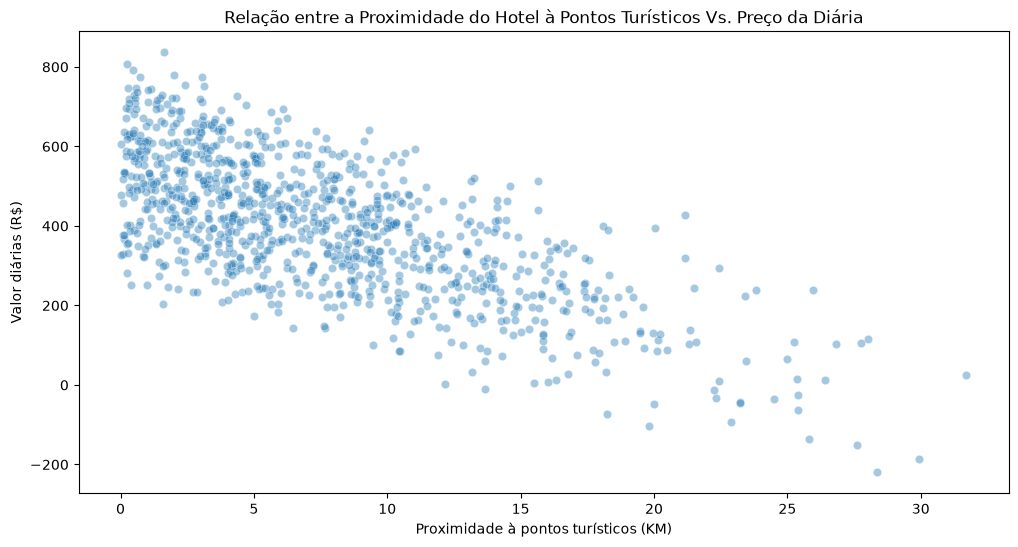

In [19]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=dados,
                x='ProximidadeTurismo',
                y='Preco',
                alpha=.4)
plt.title('Relação entre a Proximidade do Hotel à Pontos Turísticos Vs. Preço da Diária')
plt.xlabel('Proximidade à pontos turísticos (KM)')
plt.ylabel('Valor diárias (R$)')
plt.show()

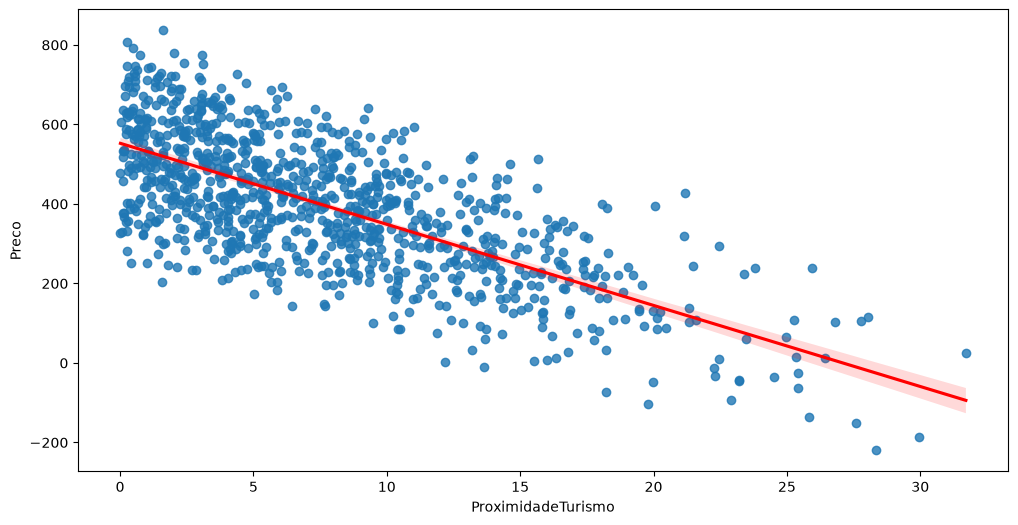

In [28]:
plt.figure(figsize=(12,6))
sns.regplot(
    data=dados,
    x='ProximidadeTurismo',
    y='Preco',
    line_kws={"color": "red"}  
)
plt.show()

---

## 3. Separando em treino e teste

In [10]:
y = dados['Preco']
X = dados.drop(columns='Preco')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=230)

print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste:  {X_test.shape[0]} registros")

Treino: 700 registros
Teste:  300 registros


---

## 4. Construindo os modelos de regressão linear

Construo três modelos com inclusão progressiva de variáveis, seguindo a ordem de correlação com o preço: começo com `Estrelas`, depois adiciono `ProximidadeTurismo` e, por último, `Capacidade`.

In [29]:
X_train_c = sm.add_constant(X_train)
X_test_c  = sm.add_constant(X_test)

### Modelo 0: apenas Estrelas

In [36]:
modelo_0 = sm.OLS(y_train, X_train_c[['const', 'Estrelas']]).fit()
print(modelo_0.summary())

                            OLS Regression Results                            
Dep. Variable:                  Preco   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     128.0
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           2.27e-27
Time:                        10:49:54   Log-Likelihood:                -4533.1
No. Observations:                 700   AIC:                             9070.
Df Residuals:                     698   BIC:                             9079.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        254.5755     14.302     17.800      0.0

### Modelo 1: Estrelas + ProximidadeTurismo

In [37]:
modelo_1 = sm.OLS(y_train, X_train_c[['const', 'Estrelas', 'ProximidadeTurismo']]).fit()
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Preco   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     625.5
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          2.79e-156
Time:                        10:50:02   Log-Likelihood:                -4232.3
No. Observations:                 700   AIC:                             8471.
Df Residuals:                     697   BIC:                             8484.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                409.2894     10

### Modelo 2: todas as variáveis

In [38]:
modelo_2 = sm.OLS(y_train, X_train_c[['const', 'Estrelas', 'ProximidadeTurismo', 'Capacidade']]).fit()
print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Preco   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     2828.
Date:                Thu, 25 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:50:50   Log-Likelihood:                -3689.2
No. Observations:                 700   AIC:                             7386.
Df Residuals:                     696   BIC:                             7405.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                195.1576      6

O modelo 2 resulta na seguinte equação:

> **Preco = 195,16 + 50,50 × Estrelas - 20,36 × ProximidadeTurismo + 81,53 × Capacidade**

Todos os coeficientes são estatisticamente significativos (p < 0,001). Interpretando cada um:

- Cada estrela adicional eleva a diária em R\\$ 50,50.
- Cada quilômetro a mais de distância dos pontos turísticos reduz a diária em R\\$ 20,36.
- Cada hóspede adicional de capacidade eleva a diária em R\\$ 81,53.

In [39]:
cols_m2 = ['const', 'Estrelas', 'ProximidadeTurismo', 'Capacidade']
vif = pd.DataFrame()
vif['variavel'] = cols_m2
vif['vif'] = [variance_inflation_factor(X_train_c[cols_m2].values, i)
              for i in range(len(cols_m2))]
print(vif)

             variavel        vif
0               const  13.034078
1            Estrelas   1.001186
2  ProximidadeTurismo   1.000167
3          Capacidade   1.001348


O VIF das variáveis explicativas fica próximo de 1,00 em todos os casos, indicando ausência total de multicolinearidade. As três variáveis carregam informação completamente independente entre si.

---

## 5. Comparando os modelos

In [40]:
pred_0 = modelo_0.predict(X_test_c[['const', 'Estrelas']])
pred_1 = modelo_1.predict(X_test_c[['const', 'Estrelas', 'ProximidadeTurismo']])
pred_2 = modelo_2.predict(X_test_c[['const', 'Estrelas', 'ProximidadeTurismo', 'Capacidade']])

print("R² (treino):")
print(f"  Modelo 0 (Estrelas):              {modelo_0.rsquared:.4f}")
print(f"  Modelo 1 (+ProximidadeTurismo):   {modelo_1.rsquared:.4f}")
print(f"  Modelo 2 (+Capacidade):           {modelo_2.rsquared:.4f}")

print("\nR² (teste):")
print(f"  Modelo 0: {r2_score(y_test, pred_0):.4f}")
print(f"  Modelo 1: {r2_score(y_test, pred_1):.4f}")
print(f"  Modelo 2: {r2_score(y_test, pred_2):.4f}")

R² (treino):
  Modelo 0 (Estrelas):              0.1550
  Modelo 1 (+ProximidadeTurismo):   0.6422
  Modelo 2 (+Capacidade):           0.9242

R² (teste):
  Modelo 0: 0.1676
  Modelo 1: 0.6645
  Modelo 2: 0.9194


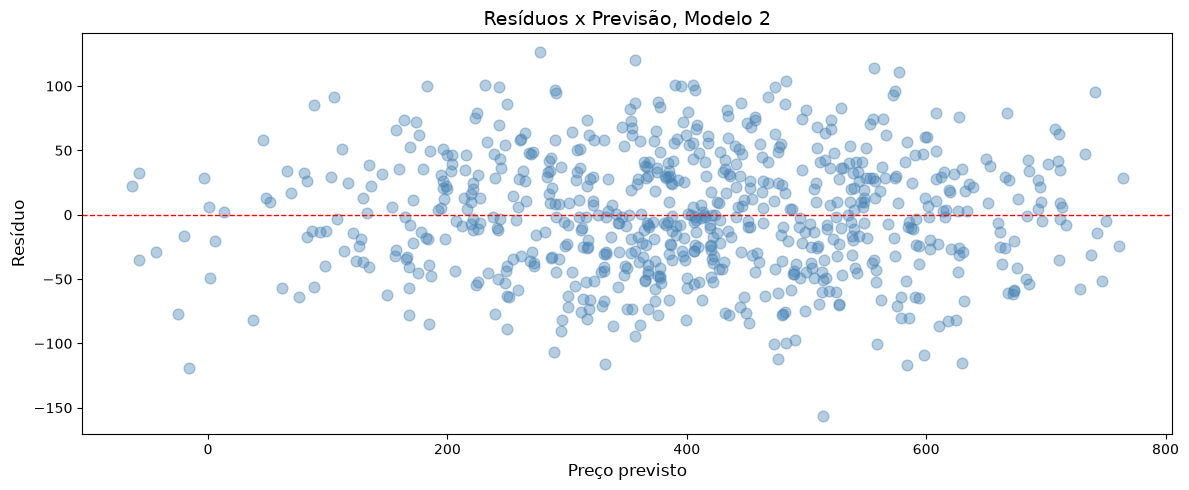

In [41]:
residuos_2 = modelo_2.resid
y_prev_train = modelo_2.predict(X_train_c[['const', 'Estrelas', 'ProximidadeTurismo', 'Capacidade']])

plt.figure(figsize=(12, 5))
plt.scatter(y_prev_train, residuos_2, alpha=0.4, color='steelblue', s=60)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Resíduos x Previsão, Modelo 2', fontsize=14)
plt.xlabel('Preço previsto', fontsize=12)
plt.ylabel('Resíduo', fontsize=12)
plt.tight_layout()
plt.show()

O gráfico de resíduos do modelo 2 mostra uma distribuição próxima ao ideal: os pontos se distribuem de forma aleatória ao redor da linha zero, sem padrão de funil ou curvatura. Isso indica homocedasticidade, ou seja, a variância dos erros é aproximadamente constante ao longo de toda a faixa de preços previstas. O modelo 2 atende bem às premissas da regressão linear.

---

## 6. Conclusão e Considerações Finais

### Síntese dos resultados

| Métrica | Valor |
|---|---|
| Observações no dataset | 1.000 |
| Proporção treino / teste | 70% / 30% |
| R² Modelo 0 (1 variável, teste) | 0,1676 |
| R² Modelo 1 (2 variáveis, teste) | 0,6645 |
| R² Modelo 2 (3 variáveis, teste) | **0,9194** |
| VIF máximo, variáveis explicativas | 1,001 |
| Maior coeficiente | `Capacidade` (+R\\$ 81,53 por hóspede) |

### Considerações Finais

A inclusão progressiva de variáveis demonstra o impacto de cada preditor no poder explicativo do modelo. `Estrelas` isolada explica apenas 16% da variação nos preços. A entrada de `ProximidadeTurismo` eleva esse número para 66%, confirmando que a localização é o fator mais determinante na precificação. Com a adição de `Capacidade`, o modelo 2 chega a R² = 0,92 no conjunto de teste, explicando 92% da variação nos preços com apenas três variáveis e resíduos com comportamento homocedástico. O VIF próximo de 1,00 em todas as variáveis confirma que os três preditores são completamente independentes entre si.

### Limitações

O dataset contém 16 registros com preço negativo, todos associados a alta distância dos pontos turísticos, o que indica um problema na geração dos dados. Em um cenário real, esses registros seriam investigados e provavelmente removidos antes da modelagem. Além disso, variáveis relevantes para precificação hoteleira, como sazonalidade, serviços inclusos, avaliações de hóspedes e localização geográfica específica, estão ausentes do dataset.

---

## 7. Referências

- Alura. **Data Science: testando relações com Regressão Linear**. Disponível em: [https://www.alura.com.br/curso-online-data-science-testando-relacoes-regressao-linear](https://www.alura.com.br/curso-online-data-science-testando-relacoes-regressao-linear). Acesso em: jun. 2026.

- Statsmodels. **Regression and Linear Models**. Disponível em: [https://www.statsmodels.org/stable/regression.html](https://www.statsmodels.org/stable/regression.html). Acesso em: jun. 2026.

- Scikit-learn. **sklearn.model_selection.train_test_split**. Disponível em: [https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Acesso em: jun. 2026.

- ESALQ/USP. **Análise de Regressão**. Disponível em: [https://www.esalq.usp.br/biblioteca/sites/default/files/Analise_Regressão.pdf](https://www.esalq.usp.br/biblioteca/sites/default/files/Analise_Regressão.pdf). Acesso em: jun. 2026.